# 03 Preprocess train, before and after (cards D2 to D6)

## Step order (card D6, option A)

Fill (D3), encode (D4) and scale (D5) here, then plain SMOTE in notebook 04. Every value is learned from train only.

## Setup

In [1]:
# Make src/ importable and load project settings and helpers
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

from stroke_prep import config, pipeline

In [2]:
# Load the training file only
train = pd.read_csv(config.TRAIN_RAW)
print("shape:", train.shape)
train.head()

shape: (3577, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,35182,Female,62.0,0,0,Yes,Govt_job,Rural,98.14,42.0,Unknown,0
1,20565,Male,13.0,0,0,No,children,Rural,85.87,24.3,Unknown,0
2,41271,Male,68.0,1,0,Yes,Govt_job,Urban,222.29,30.1,never smoked,0
3,64597,Female,33.0,0,0,Yes,Private,Rural,73.20,28.9,Unknown,0
4,50804,Male,2.0,0,0,No,children,Rural,65.84,16.1,Unknown,0


In [3]:
# Decision values from config.py (cards D3, D4, D5)
print("IMPUTE_STRATEGY:", config.IMPUTE_STRATEGY)
print("ADD_MISSING_FLAG:", config.ADD_MISSING_FLAG)
print("ONEHOT_DROP_FIRST:", config.ONEHOT_DROP_FIRST)
print("SCALER:", config.SCALER)
print("SCALE_COLUMNS:", config.SCALE_COLUMNS)

IMPUTE_STRATEGY: median
ADD_MISSING_FLAG: True
ONEHOT_DROP_FIRST: False
SCALER: StandardScaler
SCALE_COLUMNS: ['age', 'avg_glucose_level', 'bmi']


## D2 Rows and columns

In [4]:
# D2 signed card: rare value rows removed from train, and the id column dropped
RARE_ROWS = {"gender": ["Other"]}
print("rare rows rule:", RARE_ROWS)
print("columns dropped:", pipeline.DROP_COLUMNS)

rare rows rule: {'gender': ['Other']}
columns dropped: ['id']


In [5]:
# D2 how to test step 1: rows for every value of every text column in train
for col in config.RAW_CATEGORICAL:
    print(train[col].value_counts().to_dict())

{'Female': 2121, 'Male': 1455, 'Other': 1}
{'Yes': 2347, 'No': 1230}
{'Private': 2041, 'Self-employed': 585, 'children': 477, 'Govt_job': 461, 'Never_worked': 13}
{'Urban': 1832, 'Rural': 1745}
{'never smoked': 1328, 'Unknown': 1082, 'formerly smoked': 617, 'smokes': 550}


In [6]:
# D2 how to test step 2: remove the rare rows and count what was removed
train_clean = pipeline.drop_rare_rows(train, RARE_ROWS)
print("rows before:", len(train))
print("rows after:", len(train_clean))
print("rows removed:", len(train) - len(train_clean))

rows before: 3577
rows after: 3576
rows removed: 1


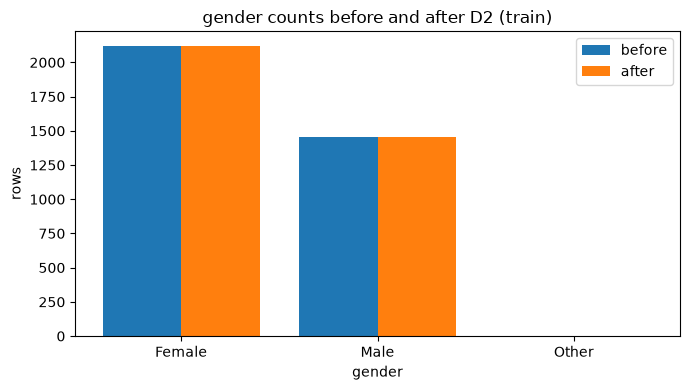

In [7]:
# Before and after chart: gender counts
before = train["gender"].value_counts()
after = train_clean["gender"].value_counts().reindex(before.index, fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(before))
ax.bar([i - 0.2 for i in x], before.values, width=0.4, label="before")
ax.bar([i + 0.2 for i in x], after.values, width=0.4, label="after")
ax.set_xticks(list(x), before.index)
ax.set_title("gender counts before and after D2 (train)")
ax.set_xlabel("gender")
ax.set_ylabel("rows")
ax.legend()
plt.tight_layout()
plt.show()

One train row had gender Other, so I removed it and train went from 3577 to 3576 rows. One row can't teach a model anything about that group. I dropped id because it's a row label, not a patient trait.

## Fit everything on train (cards D3, D4, D5)

In [8]:
# Learn fill values, encoders and the scaler from the cleaned train rows only
state = pipeline.fit_prep(train_clean)
print("columns filled:", state["fill_cols"])
learned = zip(state["fill_cols"], state["imputer"].statistics_, strict=True)
print("fill values learned:", dict(learned))

columns filled: ['bmi']
fill values learned: {'bmi': np.float64(28.1)}


In [9]:
# D2 how to test step 3: transform a made up row holding a value the encoder never saw
made_up = train_clean.head(1).copy()
made_up["gender"] = RARE_ROWS["gender"][0]
encoded = pipeline.transform(made_up, state)
print(encoded[[c for c in encoded.columns if c.startswith("gender_")]])

   gender_Female  gender_Male
0              0            0


The fill value (bmi 28.1) was learned from train only. A made up row with an unseen gender came out as all zeros in the gender columns instead of crashing, which is what handle_unknown ignore is for.

## D3 Missing values

In [10]:
# D3 how to test step 1: missing values per column in train before the step
missing_before = train_clean.isna().sum()
print(missing_before)

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  138
smoking_status         0
stroke                 0
dtype: int64


In [11]:
# D3 how to test step 3: rows with and without a missing value, on other columns and the target
has_missing = train_clean[state["fill_cols"]].isna().any(axis=1)
group = has_missing.map({True: "missing", False: "present"})
print(train_clean.groupby(group)[["age", "avg_glucose_level", "hypertension",
                                   "heart_disease", config.TARGET]].mean().round(4))

             age  avg_glucose_level  hypertension  heart_disease  stroke
missing  53.6701           131.8070        0.2391         0.1812  0.1957
present  42.7484           104.7432        0.0913         0.0474  0.0410


In [12]:
# Apply the fitted steps to train (work_type stays a text label for SMOTE)
prepared = pipeline.transform(train_clean, state)
print("shape:", prepared.shape)

shape: (3576, 18)


In [13]:
# D3 how to test step 5: missing values per column after the step
missing_after = prepared.isna().sum()
assert int(missing_after.sum()) == 0
print("missing values left:", int(missing_after.sum()))

missing values left: 0


In [14]:
# D3 flag: rows marked 1 in each missing flag column
flag_cols = [c + "_missing" for c in state["fill_cols"]]
print(prepared[flag_cols].sum().to_dict())

{'bmi_missing': 138}


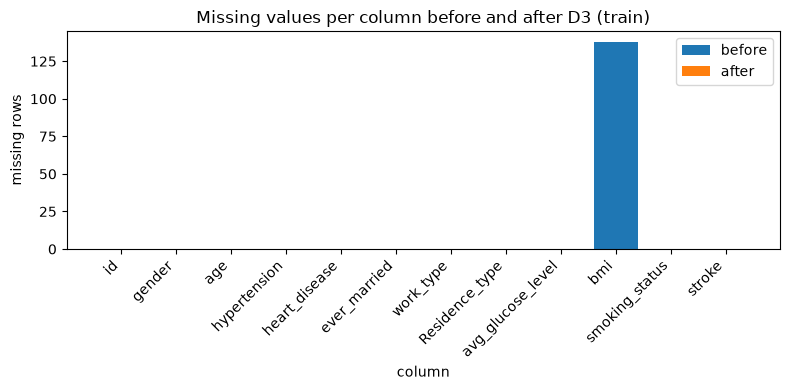

In [15]:
# Before and after chart: missing values per column
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(missing_before.index, missing_before.values, label="before")
ax.bar(missing_before.index, [int(prepared[c].isna().sum()) if c in prepared else 0
                              for c in missing_before.index], label="after")
ax.set_title("Missing values per column before and after D3 (train)")
ax.set_xlabel("column")
ax.set_ylabel("missing rows")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# D3 how to test step 2: filled columns before and after, in real units
filled_real = pipeline.to_real_units(prepared, state)
for col in state["fill_cols"]:
    print(pd.DataFrame({"before": train_clean[col].describe(),
                        "after": filled_real[col].describe()}).round(4))

          before      after
count  3438.0000  3576.0000
mean     28.9001    28.8693
std       7.9414     7.7881
min      11.3000    11.3000
25%      23.5000    23.8000
50%      28.1000    28.1000
75%      33.1000    32.8000
max      97.6000    97.6000


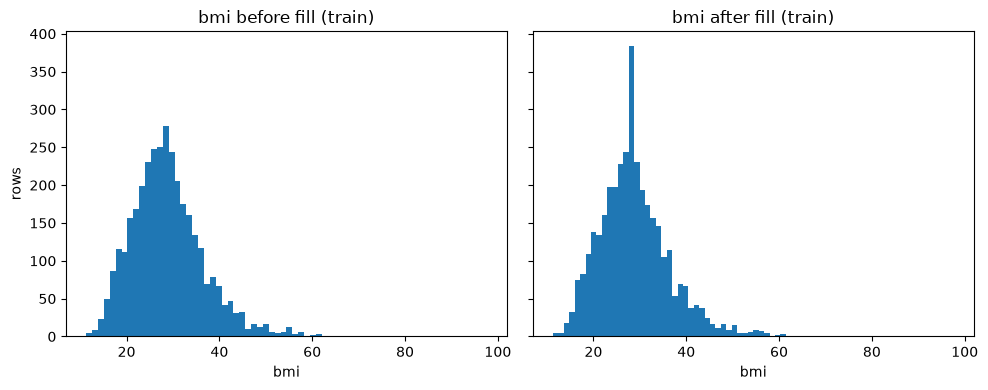

In [17]:
# Before and after chart: histogram of each filled column, in real units
for col in state["fill_cols"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    axes[0].hist(train_clean[col].dropna(), bins="auto")
    axes[0].set_title(f"{col} before fill (train)")
    axes[1].hist(filled_real[col], bins="auto")
    axes[1].set_title(f"{col} after fill (train)")
    for ax in axes:
        ax.set_xlabel(col)
    axes[0].set_ylabel("rows")
    plt.tight_layout()
    plt.show()

In [18]:
# First rows after filling (real units)
filled_real.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_missing,gender_Female,gender_Male,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type
0,62.0,0,0,98.14,42.0,0,0,1,0,0,1,1,0,1,0,0,0,Govt_job
1,13.0,0,0,85.87,24.3,0,0,0,1,1,0,1,0,1,0,0,0,children
2,68.0,1,0,222.29,30.1,0,0,0,1,0,1,0,1,0,0,1,0,Govt_job
3,33.0,0,0,73.20,28.9,0,0,1,0,0,1,1,0,1,0,0,0,Private
4,2.0,0,0,65.84,16.1,0,0,0,1,1,0,1,0,1,0,0,0,children


bmi was missing in 138 train rows. Those patients are older (age 53.7 vs 42.7), have higher glucose (131.8 vs 104.7), and have far more strokes (19.6% vs 4.1%), so the gaps aren't random. I filled them with the median 28.1 and kept a bmi_missing flag so that signal isn't lost. Missing values left: 0. The std shrank a little (7.94 to 7.79) because 138 values now sit on the median.

## D4 Encoding

In [19]:
# D4 how to test step 1: column list and count before and after encoding
cols_before = [c for c in train_clean.columns if c not in pipeline.DROP_COLUMNS]
print("before:", len(cols_before), cols_before)
print("after:", len(prepared.columns), list(prepared.columns))

before: 11 ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
after: 18 ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'bmi_missing', 'gender_Female', 'gender_Male', 'ever_married_No', 'ever_married_Yes', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'work_type']


In [20]:
# D4 how to test step 2: row sums of each one hot group on train
for name, cols in pipeline.onehot_cols(prepared.columns).items():
    print(name, prepared[cols].sum(axis=1).value_counts().to_dict())

gender {1: 3576}
ever_married {1: 3576}
Residence_type {1: 3576}
smoking_status {1: 3576}


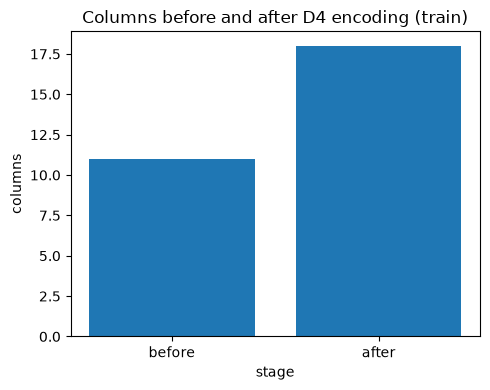

In [21]:
# Before and after chart: number of columns
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["before", "after"], [len(cols_before), len(prepared.columns)])
ax.set_title("Columns before and after D4 encoding (train)")
ax.set_xlabel("stage")
ax.set_ylabel("columns")
plt.tight_layout()
plt.show()

In [22]:
# D4 how to test step 4: first rows after encoding
prepared.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_missing,gender_Female,gender_Male,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type
0,0.836410,0,0,-0.169525,1.686225,0,0,1,0,0,1,1,0,1,0,0,0,Govt_job
1,-1.340103,0,0,-0.441514,-0.586777,0,0,0,1,1,0,1,0,1,0,0,0,children
2,1.102921,1,0,2.582515,0.158048,0,0,0,1,0,1,0,1,0,0,1,0,Govt_job
3,-0.451730,0,0,-0.722371,0.003947,0,0,1,0,0,1,1,0,1,0,0,0,Private
4,-1.828708,0,0,-0.885520,-1.639806,0,0,0,1,1,0,1,0,1,0,0,0,children


One hot encoding took the data from 11 to 18 columns. Every group sums to 1 on all 3576 rows, so each patient has exactly one value per group. I kept every column (no drop first) so each category is easy to read.

## D5 Scaling

In [23]:
# D5 how to test step 1: scaled columns before and after
print(pd.DataFrame({c: filled_real[c].describe() for c in config.SCALE_COLUMNS}).round(4))
print(prepared[config.SCALE_COLUMNS].describe().round(4))

             age  avg_glucose_level        bmi
count  3576.0000          3576.0000  3576.0000
mean     43.1698           105.7876    28.8693
std      22.5162            45.1183     7.7881
min       0.0800            55.1200    11.3000
25%      25.0000            76.6900    23.8000
50%      45.0000            91.6400    28.1000
75%      61.0000           114.0125    32.8000
max      82.0000           267.7600    97.6000


             age  avg_glucose_level        bmi
count  3576.0000          3576.0000  3576.0000
mean     -0.0000             0.0000    -0.0000
std       1.0001             1.0001     1.0001
min      -1.9140            -1.1232    -2.2562
25%      -0.8071            -0.6450    -0.6510
50%       0.0813            -0.3136    -0.0988
75%       0.7920             0.1823     0.5048
max       1.7248             3.5905     8.8263


In [24]:
# D5 how to test step 2: mean and standard deviation of each scaled column on train
print(prepared[config.SCALE_COLUMNS].agg(["mean", "std"]).round(4))

         age  avg_glucose_level     bmi
mean -0.0000             0.0000 -0.0000
std   1.0001             1.0001  1.0001


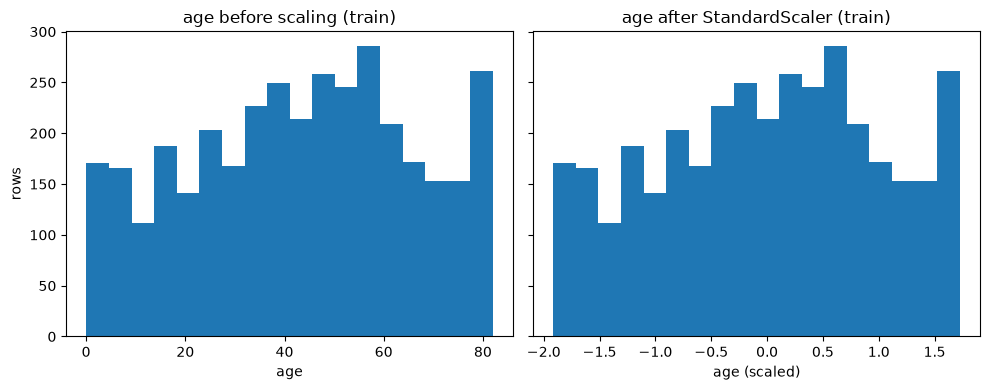

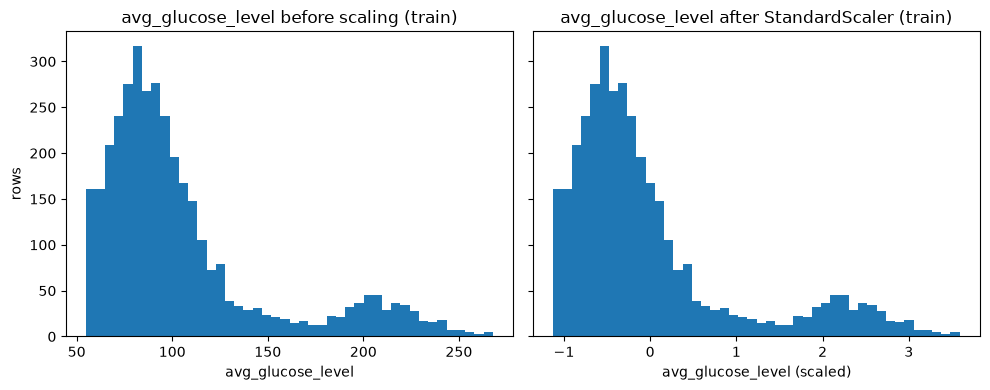

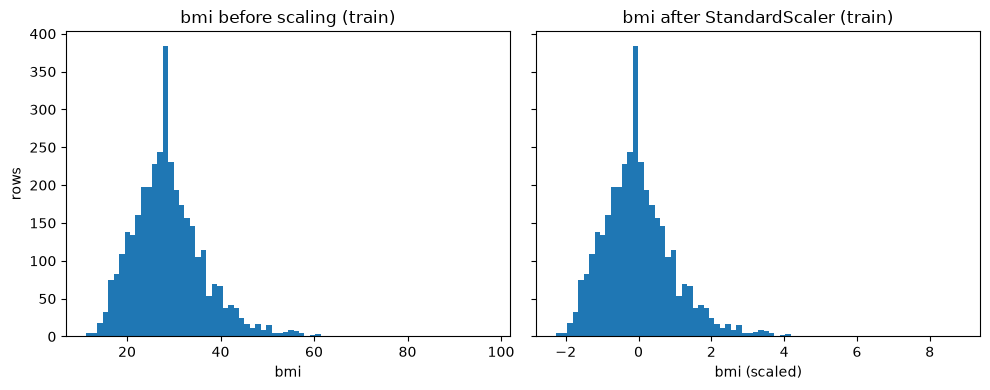

In [25]:
# Before and after chart: histogram of each scaled column
for col in config.SCALE_COLUMNS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    axes[0].hist(filled_real[col], bins="auto")
    axes[0].set_title(f"{col} before scaling (train)")
    axes[0].set_xlabel(col)
    axes[1].hist(prepared[col], bins="auto")
    axes[1].set_title(f"{col} after {config.SCALER} (train)")
    axes[1].set_xlabel(f"{col} (scaled)")
    axes[0].set_ylabel("rows")
    plt.tight_layout()
    plt.show()

Before scaling, the three numbers sat on very different scales (age mean 43.2, glucose 105.8, bmi 28.9). After StandardScaler all three have mean 0 and std 1, and the histogram shapes didn't change. The scaled bmi max is 8.83, so outliers stay outliers. I scaled only these three because the 0/1 columns are already on one scale.

## Normalization exercise (Canvas P3, card D5: shown only, not used in the final file)

In [26]:
# Fit MinMaxScaler on train and check min and max of each column
minmax = MinMaxScaler().fit(filled_real[config.SCALE_COLUMNS])
normalized = pd.DataFrame(minmax.transform(filled_real[config.SCALE_COLUMNS]),
                          columns=config.SCALE_COLUMNS)
print(normalized.agg(["min", "max"]).round(4))

     age  avg_glucose_level  bmi
min  0.0                0.0  0.0
max  1.0                1.0  1.0


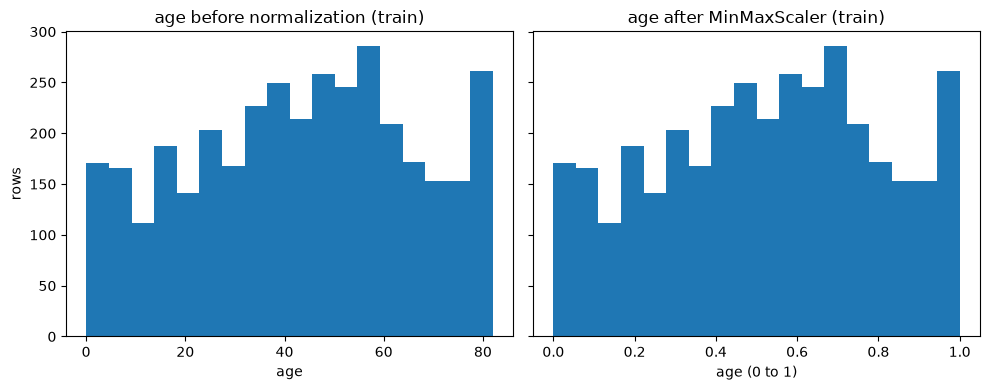

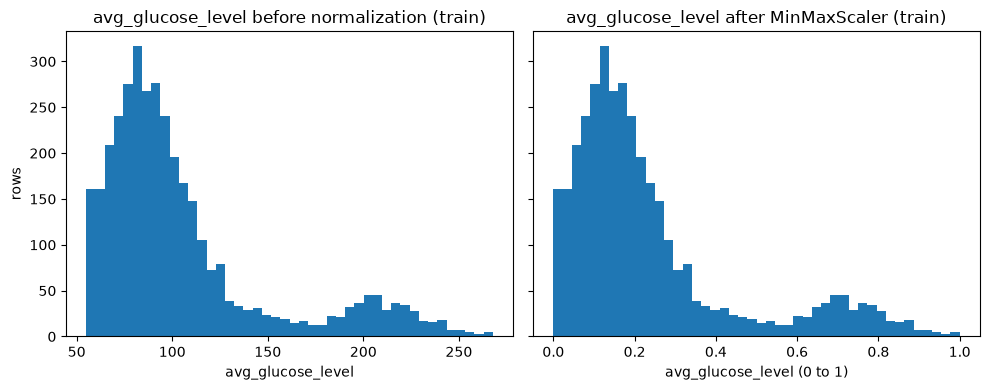

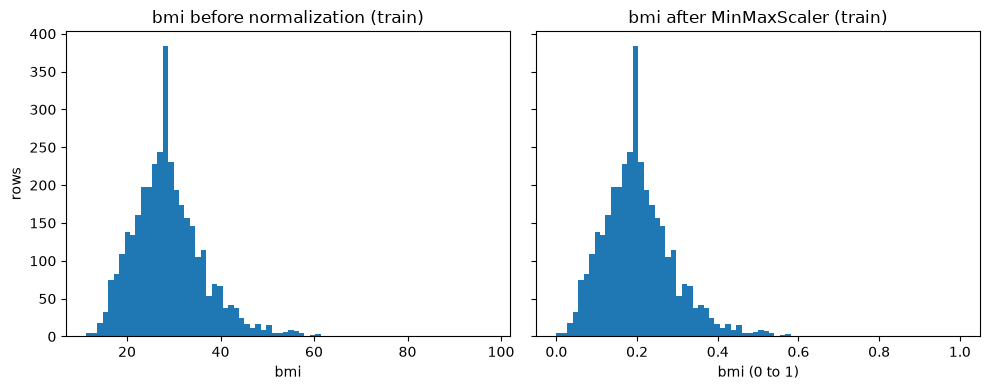

In [27]:
# Before and after chart: histogram of each column, normalized
for col in config.SCALE_COLUMNS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    axes[0].hist(filled_real[col], bins="auto")
    axes[0].set_title(f"{col} before normalization (train)")
    axes[0].set_xlabel(col)
    axes[1].hist(normalized[col], bins="auto")
    axes[1].set_title(f"{col} after MinMaxScaler (train)")
    axes[1].set_xlabel(f"{col} (0 to 1)")
    axes[0].set_ylabel("rows")
    plt.tight_layout()
    plt.show()

MinMaxScaler squeezes each column into 0 to 1 instead. The shapes look the same, but one extreme value sets the max and pushes everyone else into a narrow band. That's why I kept StandardScaler for the final file.

## Save for notebook 04

In [28]:
# Save the prepared train rows and the train fitted objects
pipeline.save_csv(prepared, config.TRAIN_PREPARED)
pipeline.STATE_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(state, pipeline.STATE_PATH)
print("saved:", config.TRAIN_PREPARED.name, pipeline.STATE_PATH.name)

saved: train_prepared.csv prep_state.joblib
